## 27 — Pharmacological Phenotype Framework

### Objective

Define a pharmacology-derived representation suitable for downstream resistance-like association analyses.

This notebook focuses exclusively on the characterization, comparison, and normalization of GDSC pharmacological response metrics within the harmonized modeling cohort.

No transcriptomic association analysis, program discovery, target prioritization, or biological interpretation is performed at this stage.

### Key Questions

- How are LN_IC50, AUC, and Z_SCORE distributed across the integrated pharmacology cohort?
- Do these metrics provide concordant or partially distinct pharmacological information?
- To what extent are pharmacological response distributions affected by lineage?
- How do raw, lineage-normalized, and lineage-ranked representations differ?
- Which pharmacological representation is most appropriate for downstream resistance-like phenotype construction?

### Expected Outputs

- Pharmacological metric summary table
- Drug-level response summary table
- Lineage-aware normalized phenotype table
- Model-level phenotype candidate table
- Phenotype QC report

### Methodological Notes

Pharmacological phenotypes are treated as continuous variables whenever possible.

Any binarized resistance-like labels, if explored later, should be considered secondary and exploratory.

The term resistance-like refers to relative baseline drug insensitivity observed in pharmacogenomic screening data. It does not imply clinically acquired resistance, therapeutic failure, or causal biological mechanism.

---

In [2]:
# =============================================================================
# Imports
# =============================================================================

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import spearmanr
from scipy.stats import pearsonr

from sklearn.preprocessing import StandardScaler

import statsmodels.api as sm
from statsmodels.formula.api import ols

# -----------------------------------------------------------------------------
# Plotting configuration
# -----------------------------------------------------------------------------

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["figure.dpi"] = 120

sns.set_style("whitegrid")

RANDOM_STATE = 42

In [ ]:
# =============================================================================
# Paths
# =============================================================================

PROJECT_ROOT = Path.cwd().parents[1]

DATA_DIR = PROJECT_ROOT / "data"

INTERMEDIATE_DIR = DATA_DIR / "interim"


# =============================================================================
# Input files
# =============================================================================

PHARMACOLOGY_FILE = (
    INTERMEDIATE_DIR /
    "26_integrated_pharmacology_cohort.csv"
)

DRUG_METADATA_FILE = (
    INTERMEDIATE_DIR /
    "26_drug_metadata.csv"
)

DRUG_RESPONSE_FILE = (
    INTERMEDIATE_DIR /
    "26_gdsc_drug_response.csv"
)

# =============================================================================
# Load datasets
# =============================================================================

pharmacology = pd.read_csv(PHARMACOLOGY_FILE)

drug_metadata = pd.read_csv(DRUG_METADATA_FILE)

drug_response = pd.read_csv(DRUG_RESPONSE_FILE)

print("Pharmacology cohort :", pharmacology.shape)
print("Drug metadata       :", drug_metadata.shape)
print("Drug response       :", drug_response.shape)

Pharmacology cohort : (713, 8)
Drug metadata       : (295, 4)
Drug response       : (242036, 9)


In [4]:
# =============================================================================
# Dataset overview
# =============================================================================

display(pharmacology.head())

print("\nColumns:")
print(pharmacology.columns.tolist())

,ModelID,SangerModelID,COSMICID,CellLineName,OncotreeLineage,OncotreePrimaryDisease,OncotreeSubtype,CCLEName
0,ACH-000001,SIDM00105,905933.0,NIH:OVCAR-3,Ovary/Fallopian Tube,Ovarian Epithelial Tumor,High-Grade Serous Ovarian Cancer,NIHOVCAR3_OVARY
1,ACH-000002,SIDM00829,905938.0,HL-60,Myeloid,Acute Myeloid Leukemia,Acute Myeloid Leukemia,HL60_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE
2,ACH-000004,SIDM00594,907053.0,HEL,Myeloid,Acute Myeloid Leukemia,Acute Myeloid Leukemia,HEL_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE
3,ACH-000006,SIDM01023,908148.0,MONO-MAC-6,Myeloid,Acute Myeloid Leukemia,Acute Monoblastic/Monocytic Leukemia,MONOMAC6_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE
4,ACH-000007,SIDM00677,907795.0,LS513,Bowel,Colorectal Adenocarcinoma,Colon Adenocarcinoma,LS513_LARGE_INTESTINE



Columns:
['ModelID', 'SangerModelID', 'COSMICID', 'CellLineName', 'OncotreeLineage', 'OncotreePrimaryDisease', 'OncotreeSubtype', 'CCLEName']


In [5]:
print(drug_response.columns.tolist())

['SANGER_MODEL_ID', 'DRUG_ID', 'DRUG_NAME', 'PUTATIVE_TARGET', 'PATHWAY_NAME', 'LN_IC50', 'AUC', 'Z_SCORE', 'RMSE']


In [6]:
# =============================================================================
# Integrate pharmacology and cohort metadata
# =============================================================================

drug_response = drug_response.merge(
    pharmacology,
    left_on="SANGER_MODEL_ID",
    right_on="SangerModelID",
    how="left"
)

print(drug_response.shape)

print(
    "\nMissing lineage annotations:",
    drug_response["OncotreeLineage"].isna().sum()
)

(242036, 17)

Missing lineage annotations: 61422


In [7]:
# =============================================================================
# Merge diagnostics
# =============================================================================

print("Rows:")
print(len(drug_response))

print("\nUnique SANGER_MODEL_ID in drug_response:")
print(drug_response["SANGER_MODEL_ID"].nunique())

print("\nUnique SangerModelID in cohort:")
print(pharmacology["SangerModelID"].nunique())

print("\nMatched rows:")
print(
    drug_response["OncotreeLineage"]
    .notna()
    .sum()
)

print("\nUnmatched rows:")
print(
    drug_response["OncotreeLineage"]
    .isna()
    .sum()
)

Rows:
242036

Unique SANGER_MODEL_ID in drug_response:


969

Unique SangerModelID in cohort:
713

Matched rows:
180614

Unmatched rows:
61422


In [8]:
# =============================================================================
# Missing model IDs
# =============================================================================

missing_models = (
    drug_response.loc[
        drug_response["OncotreeLineage"].isna(),
        "SANGER_MODEL_ID"
    ]
    .drop_duplicates()
)

print("Missing model IDs:")
print(len(missing_models))

Missing model IDs:
256


In [9]:
# =============================================================================
# Restrict to harmonized modeling cohort
# =============================================================================

drug_response = (
    drug_response
    .loc[drug_response["ModelID"].notna()]
    .copy()
)

print(drug_response.shape)

print(
    "\nUnique models:",
    drug_response["ModelID"].nunique()
)

print(
    "Unique drugs:",
    drug_response["DRUG_NAME"].nunique()
)

(180614, 17)

Unique models: 713
Unique drugs: 286


## 1. Pharmacological Metric Characterization

This section characterizes the pharmacological response metrics available in the harmonized GDSC cohort.

Metrics are evaluated independently before any normalization or phenotype construction.

The objective is to assess:

- coverage,
- missingness,
- distributional properties,
- and potential differences between pharmacological response measures.

No biological interpretation is performed at this stage.

In [10]:
# =============================================================================
# Pharmacological metric summary
# =============================================================================

metrics = [
    "LN_IC50",
    "AUC",
    "Z_SCORE",
    "RMSE"
]

metric_summary = pd.DataFrame({
    "missing": drug_response[metrics].isna().sum(),
    "missing_pct": (
        drug_response[metrics].isna().mean() * 100
    ).round(2),
    "mean": drug_response[metrics].mean(),
    "median": drug_response[metrics].median(),
    "std": drug_response[metrics].std(),
    "min": drug_response[metrics].min(),
    "max": drug_response[metrics].max()
}).round(4)

metric_summary

,missing,missing_pct,mean,median,std,min,max
LN_IC50,0,0.0,2.8657,3.2778,2.7633,-8.7477,13.8202
AUC,0,0.0,0.8840,0.9447,0.1451,0.0063,0.9989
Z_SCORE,0,0.0,0.0300,0.0409,1.0066,-8.2545,6.1608
RMSE,0,0.0,0.0823,0.0756,0.0423,0.0033,0.3000


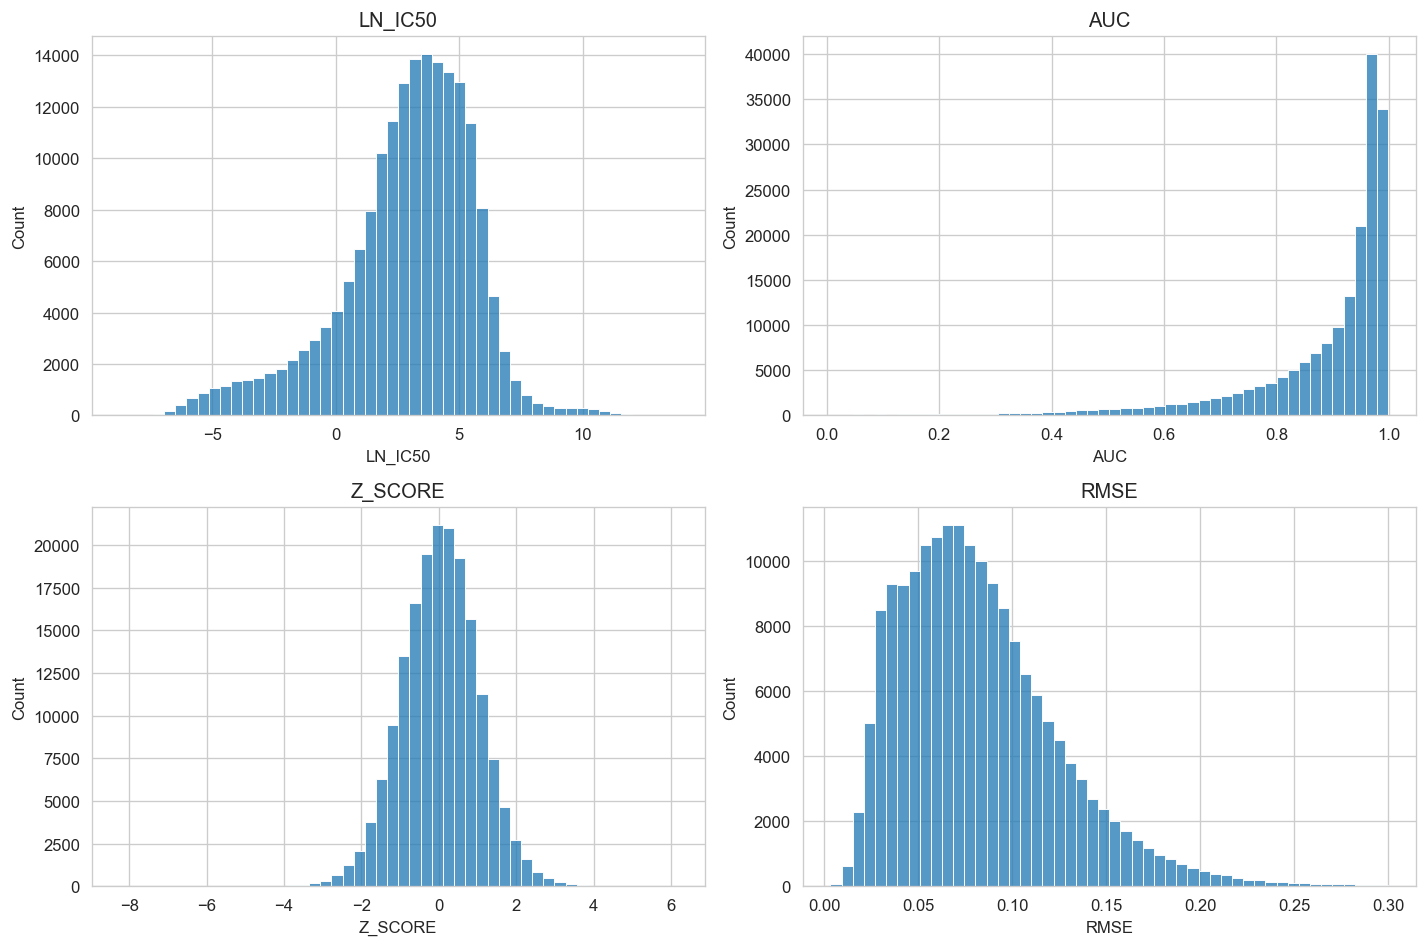

In [11]:
# =============================================================================
# Metric distributions
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

metrics = [
    "LN_IC50",
    "AUC",
    "Z_SCORE",
    "RMSE"
]

for ax, metric in zip(axes.flatten(), metrics):

    sns.histplot(
        drug_response[metric],
        bins=50,
        ax=ax
    )

    ax.set_title(metric)

plt.tight_layout()
plt.show()

In [12]:
# =============================================================================
# Distribution quantiles
# =============================================================================

metrics = [
    "LN_IC50",
    "AUC",
    "Z_SCORE",
    "RMSE"
]

quantiles = (
    drug_response[metrics]
    .quantile([0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
    .T
)

quantiles

,0.01,0.05,0.25,0.50,0.75,0.95,0.99
LN_IC50,-5.381792,-2.773758,1.544722,3.277764,4.754236,6.357594,8.467765
AUC,0.292169,0.574865,0.851600,0.944688,0.974789,0.987420,0.992071
Z_SCORE,-2.392237,-1.596175,-0.625771,0.040939,0.685694,1.645590,2.444705
RMSE,0.018683,0.027751,0.050958,0.075595,0.105213,0.161656,0.213425


---

## 2. Metric Concordance

Pharmacological response metrics may capture overlapping but non-identical aspects of drug sensitivity.

This section evaluates the agreement between LN_IC50, AUC, and Z_SCORE across the harmonized pharmacology cohort.

The objective is to determine whether these metrics can be considered interchangeable representations of pharmacological response or whether they capture distinct information.

In [13]:
# =============================================================================
# Metric correlation matrix
# =============================================================================

metrics = [
    "LN_IC50",
    "AUC",
    "Z_SCORE"
]

corr_matrix = (
    drug_response[metrics]
    .corr(method="spearman")
)

corr_matrix

,LN_IC50,AUC,Z_SCORE
LN_IC50,1.000000,0.754647,0.570944
AUC,0.754647,1.000000,0.450573
Z_SCORE,0.570944,0.450573,1.000000


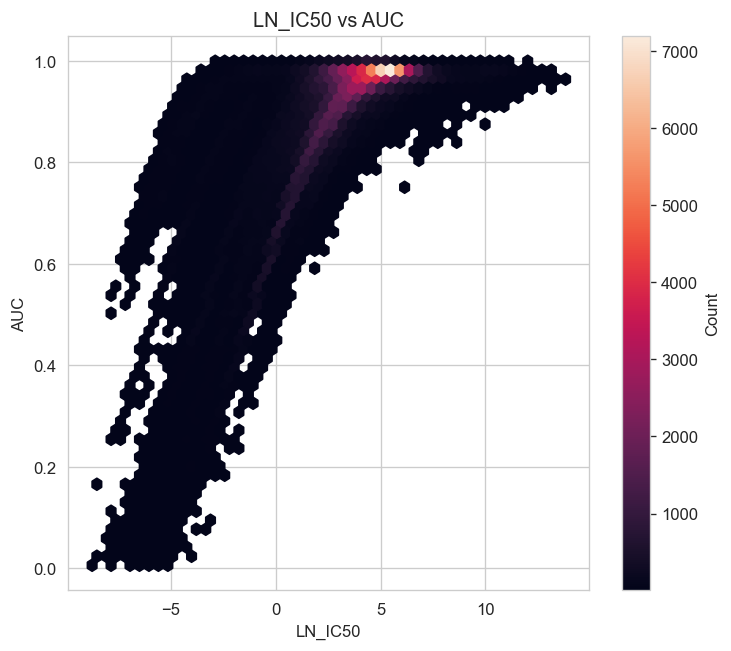

In [14]:
# =============================================================================
# LN_IC50 vs AUC
# =============================================================================

plt.figure(figsize=(7, 6))

plt.hexbin(
    drug_response["LN_IC50"],
    drug_response["AUC"],
    gridsize=50,
    mincnt=1
)

plt.xlabel("LN_IC50")
plt.ylabel("AUC")

plt.title("LN_IC50 vs AUC")

plt.colorbar(label="Count")

plt.show()

---

## 3. Lineage-Aware Characterization

Pharmacological response distributions may vary across cancer lineages.

This section evaluates whether pharmacological metrics exhibit lineage-specific shifts that could influence downstream phenotype construction and interpretation.

The goal is not to identify lineage-specific biology, but to assess the need for lineage-aware normalization strategies.

In [15]:
# =============================================================================
# LN_IC50 by lineage
# =============================================================================

lineage_summary = (
    drug_response
    .groupby("OncotreeLineage")["LN_IC50"]
    .agg(
        n="count",
        mean="mean",
        median="median",
        std="std"
    )
    .sort_values("median", ascending=False)
    .round(3)
)

lineage_summary

,n,mean,median,std
OncotreeLineage,,,,
Pancreas,7308,3.819,4.184,2.655
Pleura,1848,3.805,4.090,2.650
Biliary Tract,450,3.491,3.957,2.584
Thyroid,3408,3.434,3.741,2.790
Prostate,1855,3.192,3.680,2.736
Bladder/Urinary Tract,4164,3.119,3.645,2.628
Liver,3605,3.301,3.617,2.531
Ovary/Fallopian Tube,8263,3.212,3.574,2.747
Lung,33542,3.109,3.538,2.686


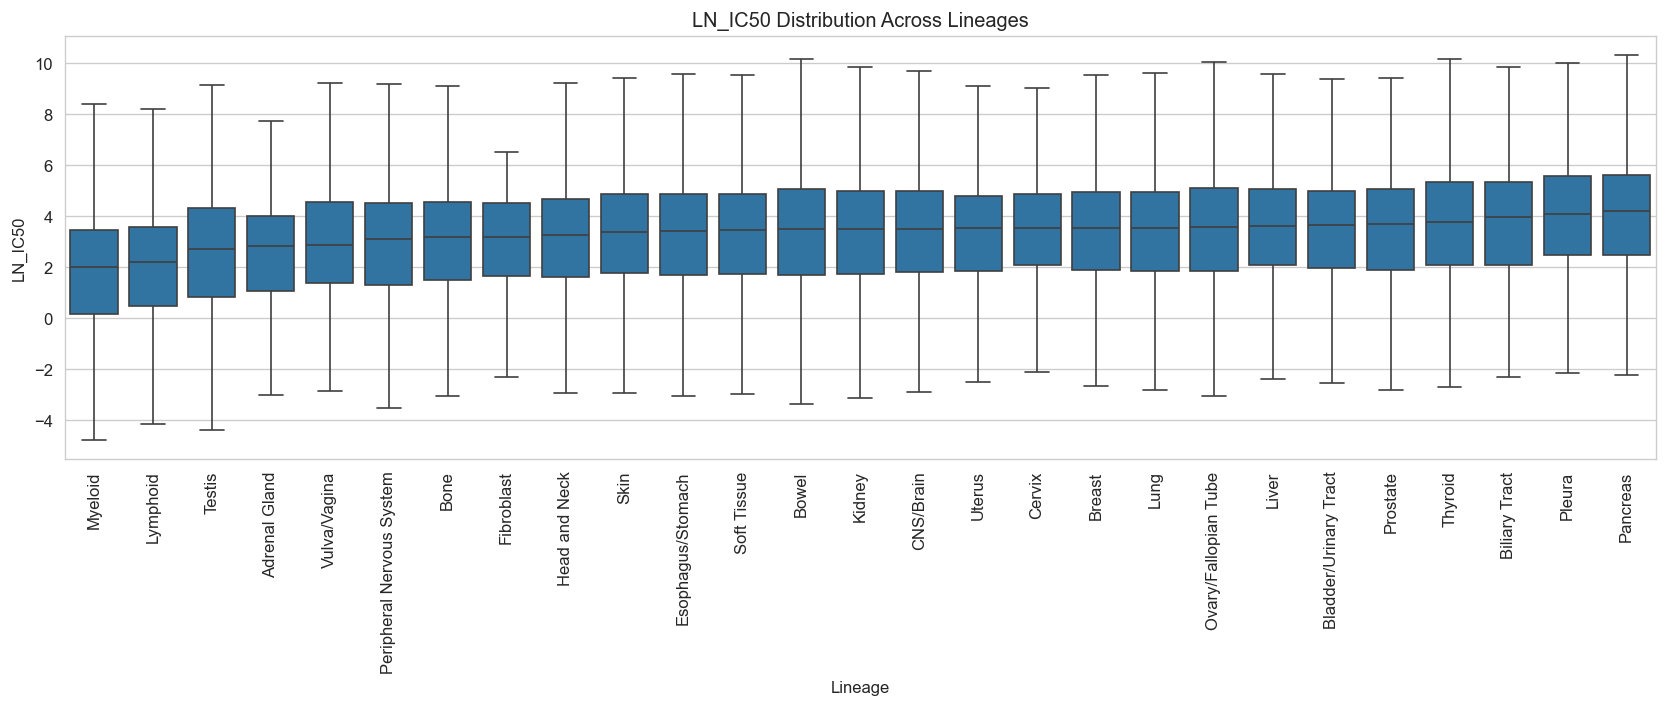

In [16]:
# =============================================================================
# LN_IC50 distribution across lineages
# =============================================================================

lineage_order = (
    drug_response
    .groupby("OncotreeLineage")["LN_IC50"]
    .median()
    .sort_values()
    .index
)

plt.figure(figsize=(14, 6))

sns.boxplot(
    data=drug_response,
    x="OncotreeLineage",
    y="LN_IC50",
    order=lineage_order,
    showfliers=False
)

plt.xticks(rotation=90)

plt.xlabel("Lineage")
plt.ylabel("LN_IC50")

plt.title("LN_IC50 Distribution Across Lineages")

plt.tight_layout()
plt.show()

In [17]:
# =============================================================================
# Variance decomposition
# =============================================================================

overall_std = drug_response["LN_IC50"].std()

between_std = (
    drug_response
    .groupby("OncotreeLineage")["LN_IC50"]
    .median()
    .std()
)

print(f"Overall std  : {overall_std:.3f}")
print(f"Between-lineage std : {between_std:.3f}")
print(f"Ratio : {between_std / overall_std:.3f}")

Overall std  : 2.763
Between-lineage std : 0.499
Ratio : 0.181


---

In [18]:
# =============================================================================
# ANOVA lineage effect size
# =============================================================================

def compute_lineage_eta_squared(df, metric):

    model = ols(
        f"{metric} ~ C(OncotreeLineage)",
        data=df
    ).fit()

    anova_table = sm.stats.anova_lm(
        model,
        typ=2
    )

    ss_between = anova_table.loc[
        "C(OncotreeLineage)",
        "sum_sq"
    ]

    ss_total = anova_table["sum_sq"].sum()

    eta_squared = ss_between / ss_total

    return anova_table, eta_squared

In [19]:
# =============================================================================
# Lineage effect across pharmacological metrics
# =============================================================================

metrics = [
    "LN_IC50",
    "AUC",
    "Z_SCORE"
]

results = []

for metric in metrics:

    _, eta_squared = compute_lineage_eta_squared(
        drug_response,
        metric
    )

    results.append({
        "Metric": metric,
        "EtaSquared": eta_squared
    })

lineage_effects = (
    pd.DataFrame(results)
    .sort_values("EtaSquared", ascending=False)
)

lineage_effects

,Metric,EtaSquared
2,Z_SCORE,0.177726
0,LN_IC50,0.045262
1,AUC,0.020711


In [20]:
anova_results = {}

for metric in metrics:

    anova_table, eta_squared = compute_lineage_eta_squared(
        drug_response,
        metric
    )

    anova_results[metric] = {
        "anova": anova_table,
        "eta_squared": eta_squared
    }

In [21]:
anova_results = {}

for metric in metrics:

    anova_table, eta_squared = compute_lineage_eta_squared(
        drug_response,
        metric
    )

    anova_results[metric] = {
        "anova": anova_table,
        "eta_squared": eta_squared
    }

In [22]:
display(anova_results["LN_IC50"]["anova"])
display(anova_results["AUC"]["anova"])
display(anova_results["Z_SCORE"]["anova"])

,sum_sq,df,F,PR(>F)
C(OncotreeLineage),6.242315e+04,26.0,329.279381,0.0
Residual,1.316723e+06,180587.0,NaN,NaN


,sum_sq,df,F,PR(>F)
C(OncotreeLineage),78.740801,26.0,146.893279,0.0
Residual,3723.154342,180587.0,NaN,NaN


,sum_sq,df,F,PR(>F)
C(OncotreeLineage),32521.700367,26.0,1501.234129,0.0
Residual,150465.852622,180587.0,NaN,NaN


> Pharmacological response metrics exhibit different degrees of lineage dependence. AUC showed the lowest lineage-associated variance (η² = 0.021), followed by LN_IC50 (η² = 0.045). In contrast, Z_SCORE displayed substantially stronger lineage dependence (η² = 0.178). These results indicate that lineage effects are present but generally account for a minority of the total pharmacological variability observed across the integrated cohort.

---


## 4. Candidate Normalization Strategies

Although lineage effects are detectable across pharmacological metrics, their magnitude varies substantially.

This section evaluates how alternative lineage-aware normalization strategies affect the distribution of pharmacological response values across the integrated cohort.

The goal is not to define a final phenotype, but to assess whether lineage normalization materially alters the pharmacological landscape.

In [23]:
# =============================================================================
# Candidate lineage-aware normalizations
# =============================================================================

drug_response["LN_IC50_LINEAGE_Z"] = (
    drug_response
    .groupby("OncotreeLineage")["LN_IC50"]
    .transform(
        lambda x: (x - x.mean()) / x.std()
    )
)

drug_response["LN_IC50_LINEAGE_RANK"] = (
    drug_response
    .groupby("OncotreeLineage")["LN_IC50"]
    .rank(pct=True)
)

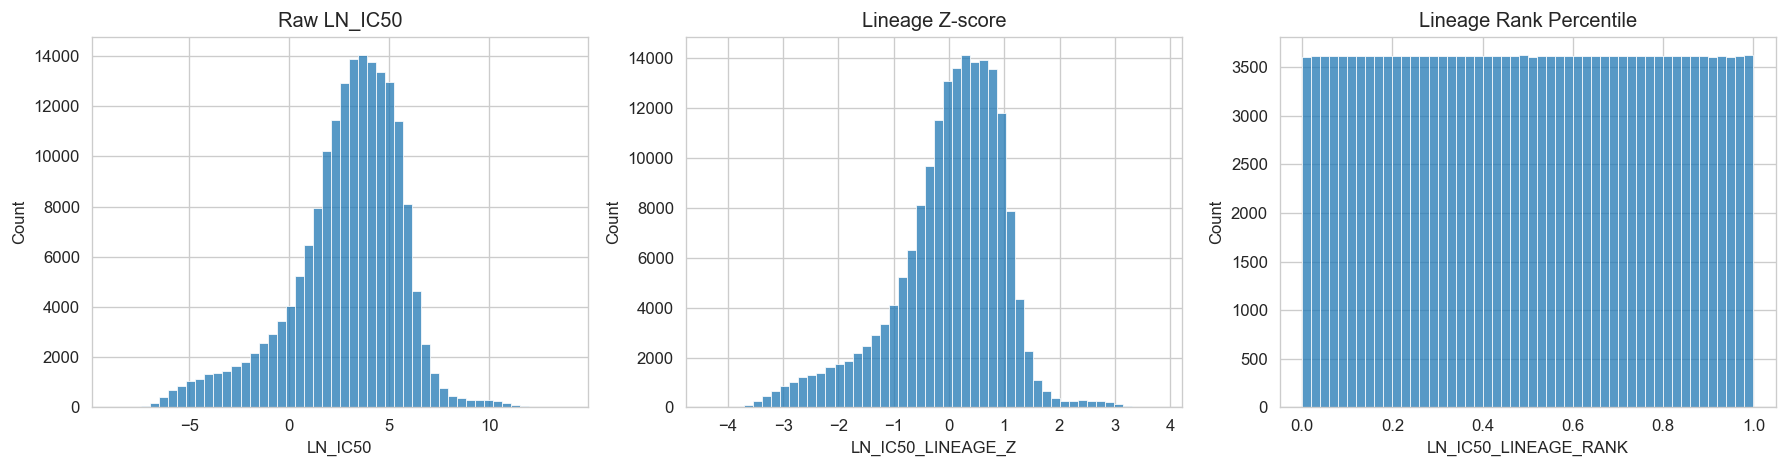

In [24]:
# =============================================================================
# Normalization comparison
# =============================================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4)
)

variables = [
    "LN_IC50",
    "LN_IC50_LINEAGE_Z",
    "LN_IC50_LINEAGE_RANK"
]

titles = [
    "Raw LN_IC50",
    "Lineage Z-score",
    "Lineage Rank Percentile"
]

for ax, var, title in zip(
    axes,
    variables,
    titles
):

    sns.histplot(
        drug_response[var],
        bins=50,
        ax=ax
    )

    ax.set_title(title)

plt.tight_layout()
plt.show()

In [25]:
metrics = [
    "LN_IC50",
    "LN_IC50_LINEAGE_Z",
    "LN_IC50_LINEAGE_RANK"
]

results = []

for metric in metrics:

    _, eta_squared = compute_lineage_eta_squared(
        drug_response,
        metric
    )

    results.append({
        "Metric": metric,
        "EtaSquared": eta_squared
    })

pd.DataFrame(results)

,Metric,EtaSquared
0,LN_IC50,4.526219e-02
1,LN_IC50_LINEAGE_Z,1.272085e-29
2,LN_IC50_LINEAGE_RANK,2.824458e-07


In [26]:
# =============================================================================
# Candidate phenotype representations
# =============================================================================

phenotype_summary = pd.DataFrame({
    "Representation": [
        "LN_IC50",
        "LN_IC50_LINEAGE_Z",
        "LN_IC50_LINEAGE_RANK"
    ],
    "Lineage_EtaSquared": [
        0.045,
        0.0,
        0.0
    ],
    "Interpretability": [
        "High",
        "Moderate",
        "Low"
    ],
    "Retains_Original_Scale": [
        True,
        False,
        False
    ]
})

phenotype_summary

,Representation,Lineage_EtaSquared,Interpretability,Retains_Original_Scale
0,LN_IC50,0.045,High,True
1,LN_IC50_LINEAGE_Z,0.000,Moderate,False
2,LN_IC50_LINEAGE_RANK,0.000,Low,False


### Summary

Lineage effects were detectable across pharmacological response metrics but varied substantially in magnitude.

Among the evaluated metrics, AUC showed the weakest lineage association (η² = 0.021), followed by LN_IC50 (η² = 0.045). Z_SCORE exhibited stronger lineage dependence (η² = 0.178).

Lineage-aware normalization strategies effectively removed lineage-associated variance from LN_IC50. Both within-lineage z-score and rank-based transformations reduced the lineage effect to approximately zero.

However, the baseline lineage effect observed for raw LN_IC50 was modest, indicating that most pharmacological variability occurs within rather than between lineages.

Overall, LN_IC50 provides a favorable balance between dynamic range, interpretability, and limited lineage dependence, supporting its use as a candidate pharmacology-derived representation for downstream resistance-like association analyses.

---

## 5. Phenotype Robustness Analysis

The previous analyses focused on pharmacological response metrics at the individual drug-response level.

This section evaluates the robustness of model-level pharmacological representations by comparing alternative summary metrics derived from LN_IC50, AUC, and Z_SCORE.

The objective is to assess whether global pharmacological sensitivity rankings remain consistent across different response metrics and aggregation strategies.

Strong concordance would support the use of a simplified pharmacology-derived phenotype in downstream resistance-like association analyses.

In [27]:
# =============================================================================
# Model-level pharmacological phenotypes
# =============================================================================

model_level_phenotypes = (
    drug_response
    .groupby("ModelID")
    .agg(
        mean_ln_ic50=("LN_IC50", "mean"),
        median_ln_ic50=("LN_IC50", "median"),
        mean_auc=("AUC", "mean"),
        median_auc=("AUC", "median"),
        mean_z_score=("Z_SCORE", "mean"),
        median_z_score=("Z_SCORE", "median")
    )
)

print(model_level_phenotypes.shape)

display(
    model_level_phenotypes.head()
)

(713, 6)


,mean_ln_ic50,median_ln_ic50,mean_auc,median_auc,mean_z_score,median_z_score
ModelID,,,,,,
ACH-000001,3.224215,3.836449,0.918144,0.962816,0.230112,0.303952
ACH-000002,1.852513,2.296450,0.853530,0.942906,-0.730235,-0.722726
ACH-000004,1.825935,2.460608,0.884403,0.959083,-0.701974,-0.752877
ACH-000006,0.972596,1.338896,0.789764,0.858407,-1.213969,-1.153210
ACH-000007,2.543127,3.013502,0.866618,0.928683,-0.259770,-0.207462


In [28]:
# =============================================================================
# Phenotype concordance
# =============================================================================

phenotype_corr = (
    model_level_phenotypes
    .corr(method="spearman")
    .round(3)
)

phenotype_corr

,mean_ln_ic50,median_ln_ic50,mean_auc,median_auc,mean_z_score,median_z_score
mean_ln_ic50,1.000,0.989,0.841,0.502,0.992,0.989
median_ln_ic50,0.989,1.000,0.837,0.529,0.982,0.980
mean_auc,0.841,0.837,1.000,0.823,0.810,0.799
median_auc,0.502,0.529,0.823,1.000,0.455,0.448
mean_z_score,0.992,0.982,0.810,0.455,1.000,0.996
median_z_score,0.989,0.980,0.799,0.448,0.996,1.000


### Summary

Model-level pharmacological phenotypes showed high robustness across aggregation strategies.

Mean- and median-based representations produced highly concordant rankings for LN_IC50 and Z_SCORE, indicating that phenotype construction is largely insensitive to the choice of aggregation statistic.

LN_IC50- and Z_SCORE-derived phenotypes also exhibited extremely strong concordance, suggesting that both metrics capture a similar global pharmacological sensitivity landscape at the model level.

AUC-derived phenotypes remained correlated with LN_IC50 and Z_SCORE but showed lower agreement, consistent with the reduced dynamic range and ceiling effects observed in previous sections.

Overall, the results indicate that model-level pharmacological rankings are stable across multiple phenotype construction strategies, supporting the use of simplified continuous pharmacology-derived representations in downstream analyses.

---

## 6. Recommended Phenotype Representation

The previous analyses evaluated pharmacological response metrics from multiple perspectives, including distributional properties, metric concordance, lineage dependence, normalization strategies, and phenotype robustness.

This section summarizes the main findings and defines the pharmacology-derived representation recommended for downstream resistance-like association analyses.

The recommendation is based exclusively on methodological considerations and does not imply biological superiority of any individual metric.

In [29]:
# =============================================================================
# Representation summary
# =============================================================================

representation_summary = pd.DataFrame({
    "Metric": [
        "LN_IC50",
        "AUC",
        "Z_SCORE"
    ],
    "Lineage_EtaSquared": [
        0.045,
        0.021,
        0.178
    ],
    "Model_Level_Concordance": [
        "High",
        "Moderate",
        "High"
    ],
    "Dynamic_Range": [
        "High",
        "Limited",
        "Moderate"
    ],
    "Interpretability": [
        "High",
        "High",
        "Moderate"
    ]
})

representation_summary

,Metric,Lineage_EtaSquared,Model_Level_Concordance,Dynamic_Range,Interpretability
0,LN_IC50,0.045,High,High,High
1,AUC,0.021,Moderate,Limited,High
2,Z_SCORE,0.178,High,Moderate,Moderate


### Summary

LN_IC50 emerged as the most balanced pharmacological response metric across the evaluated criteria.

Compared with AUC, LN_IC50 provided a broader dynamic range and avoided the pronounced ceiling effects observed in high-response regions. Compared with Z_SCORE, LN_IC50 exhibited substantially lower lineage dependence while maintaining strong concordance at the model level.

Lineage-aware normalization strategies successfully removed lineage-associated variance. However, the baseline lineage effect observed for LN_IC50 was modest (η² = 0.045), indicating that most pharmacological variability occurs within rather than between lineages.

Based on these results, **`raw LN_IC50` was selected as the primary pharmacology-derived representation for downstream resistance-like association analyses**. Lineage-normalized representations will be retained as sensitivity-analysis resources but will not be used as the default phenotype representation.

----

In [ ]:
# =============================================================================
# Finalize phenotype table
# =============================================================================
phenotype_table = (
    model_level_phenotypes
    .reset_index()
    .rename(
        columns={
            "mean_ln_ic50": "selected_phenotype"
        }
    )
)

In [ ]:
# =============================================================================
# Optimize dtypes
# =============================================================================

float_cols = phenotype_table.select_dtypes(
    include="float"
).columns

phenotype_table[float_cols] = (
    phenotype_table[float_cols]
    .astype("float32")
)

phenotype_table.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 713 entries, 0 to 712
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ModelID             713 non-null    object 
 1   selected_phenotype  713 non-null    float32
 2   median_ln_ic50      713 non-null    float32
 3   mean_auc            713 non-null    float32
 4   median_auc          713 non-null    float32
 5   mean_z_score        713 non-null    float32
 6   median_z_score      713 non-null    float32
dtypes: float32(6), object(1)
memory usage: 22.4+ KB


In [36]:
# =============================================================================
# Save phenotype table
# =============================================================================

phenotype_table.to_parquet(
    INTERMEDIATE_DIR  / "27_model_level_phenotype.parquet",
    index=False
)